<a href="https://colab.research.google.com/github/AnhNgoc201/Deeplearning/blob/main/Thuchanh_Tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Huấn luyện model bằng mô hình CNN


## Cài đặt thư viện

In [44]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

## Đọc dữ liệu MNIST

In [46]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

## Trực quan hóa 10 ảnh đầu

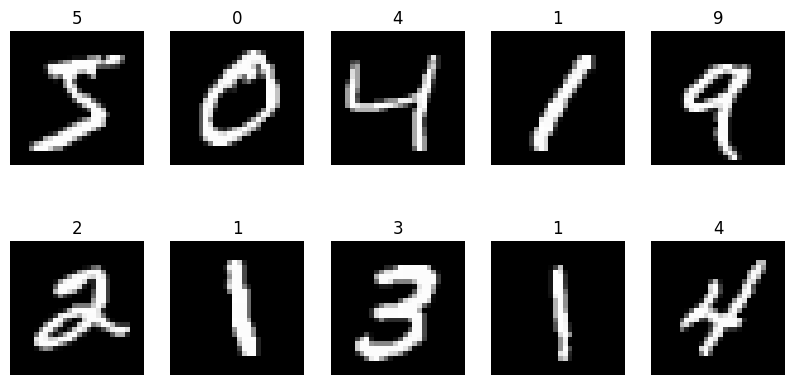

In [47]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

## Tiền xử lí dữ liệu

### Chuẩn hóa

In [48]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Reshape

In [49]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

### One-hot encoding

In [50]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## Xây dựng mô hình CNN

In [51]:
model = models.Sequential()

# Convolution + ReLU + Pooling
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten + Dense
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

## Compile model

In [52]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Huấn luyện model

In [53]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.9581 - loss: 0.1381 - val_accuracy: 0.9798 - val_loss: 0.0554
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9859 - loss: 0.0457 - val_accuracy: 0.9880 - val_loss: 0.0381
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9897 - loss: 0.0323 - val_accuracy: 0.9915 - val_loss: 0.0278
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9928 - loss: 0.0231 - val_accuracy: 0.9889 - val_loss: 0.0336
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.9940 - loss: 0.0183 - val_accuracy: 0.9906 - val_loss: 0.0305
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9957 - loss: 0.0131 - val_accuracy: 0.9900 - val_loss: 0.0314
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9962 - loss: 0.0110 - val_accuracy: 0.9910 - val_loss: 0.0314
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9966 -

## Đánh giá mô hình

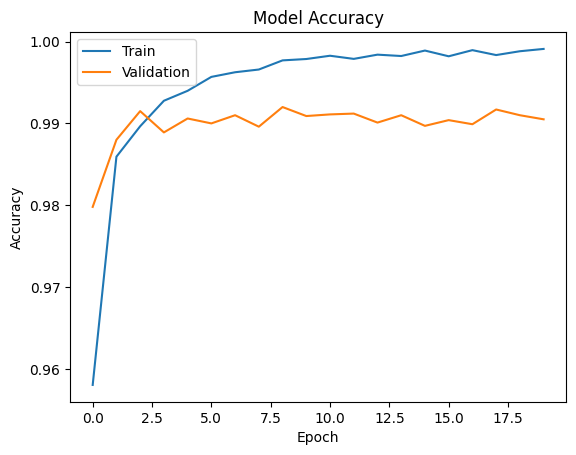

In [54]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

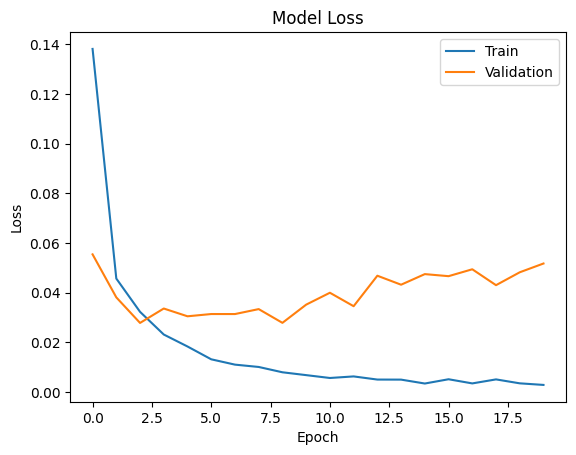

In [63]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

## Dự đoán thử

In [55]:
import numpy as np

pred = model.predict(X_test)

print("Dự đoán:", np.argmax(pred[0]))
print("Thực tế:", np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Dự đoán: 7
Thực tế: 7


## Lưu model

In [56]:
model.save("cnn_mnist.h5")

## Dự đoán ảnh thật

In [61]:
from PIL import Image
import numpy as np

img = Image.open("/content/h3.PNG").convert('L')  # grayscale
img = img.resize((28,28))

img = np.array(img)

# đảo màu (nếu nền trắng)
img = 255 - img

# normalize
img = img / 255.0

# reshape
img = img.reshape(1,28,28,1)

In [62]:
pred = model.predict(img)
print("Dự đoán:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Dự đoán: 1
